## <b>Pre-processing.</b>

In [1]:
import torch
import random
import numpy as np

# 1. Set the seed for Python's built-in random number generator
random.seed(42)

# 2. Set the seed for Numpy
np.random.seed(42)

# 3. Set the seed for PyTorch (CPU and GPU)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# 4. Force PyTorch to use deterministic algorithms
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random seeds locked to 42. Training is now reproducible.")

Random seeds locked to 42. Training is now reproducible.


In [2]:
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
import torch.nn as nn   # this functions builds the neurons
import torch.optim as optim   # optim does the gradient descent
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 490kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.2MB/s]


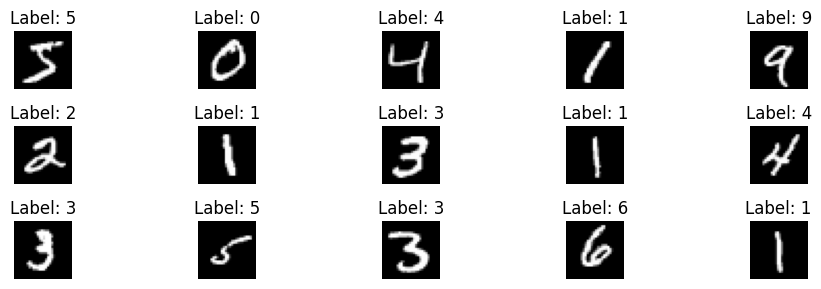

In [3]:
raw_train_data = datasets.MNIST(root='./data', train=True, download=True)

fig, axes = plt.subplots(3, 5, figsize=(10, 3))
for i in range(15):
    img, label = raw_train_data[i]
    axes.flatten()[i].imshow(img, cmap='gray')
    axes.flatten()[i].set_title(f'Label: {label}')
    axes.flatten()[i].axis('off')
plt.tight_layout()
plt.show()

In [4]:
# Convert the images to PyTorch Tensors and normalize the pixel values from [0, 1] to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# --- 3. LOAD TRANSFORMED DATA ---
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
val_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# We initialize the loaders here for our main training loop
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)

## <b>The Architecture</b>

The network takes a 28x28 pixel grayscale image, sweeps over it with Convolutional filters to find edges and curves, compresses it with Max Pooling, and then uses a Fully Connected (Linear) layer to guess which of the 10 digits (0-9) it is.

In [13]:
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()
    # 1 input channel, K=16, F=3
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
    self.relu = nn.ReLU()
    self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
    # after maxpool, 28x28 image becomes 14x14

    # classifier head: flattens the feature map and classifies them into 10 buckets
    # 16 filters * 14 width * 14 height = 3136 features
    self.fc = nn.Linear(in_features=3136, out_features=10)

  # defining forward pass
  def forward(self, x):
    x = self.conv1(x)
    x = self.relu(x)
    x = self.maxpool(x)

    # flatten the 2d image into 1d vector for the classifier FFNN
    x = torch.flatten(x,1)
    x = self.fc(x)
    return x


# setting up model
model = CNN()
model = model.to(device)

## <b>Training the Model </b>

In [ ]:
import torch.nn as nn
import torch.optim as optim

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 10
train_loss_history = []
val_loss_history = []
val_acc_history = []

print("Starting Training...\n")

for e in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    total_train_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # --- VALIDATION PHASE ---
    model.eval()
    total_val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad(): # Stop tracking gradients for validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_loss_history.append(avg_val_loss)

    val_accuracy = correct / total
    val_acc_history.append(val_accuracy)

    print(f"Epoch {e+1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.4f}")

Starting Training...

Epoch 01 | Train Loss: 0.2641 | Val Loss: 0.1049 | Val Acc: 0.9689
Epoch 02 | Train Loss: 0.0942 | Val Loss: 0.0813 | Val Acc: 0.9735
Epoch 03 | Train Loss: 0.0703 | Val Loss: 0.0658 | Val Acc: 0.9799
Epoch 04 | Train Loss: 0.0578 | Val Loss: 0.0718 | Val Acc: 0.9790
Epoch 05 | Train Loss: 0.0509 | Val Loss: 0.0654 | Val Acc: 0.9804
Epoch 06 | Train Loss: 0.0449 | Val Loss: 0.0616 | Val Acc: 0.9818
Epoch 07 | Train Loss: 0.0400 | Val Loss: 0.0608 | Val Acc: 0.9815
Epoch 08 | Train Loss: 0.0359 | Val Loss: 0.0581 | Val Acc: 0.9817
Epoch 09 | Train Loss: 0.0320 | Val Loss: 0.0683 | Val Acc: 0.9786
Epoch 10 | Train Loss: 0.0296 | Val Loss: 0.0703 | Val Acc: 0.9801


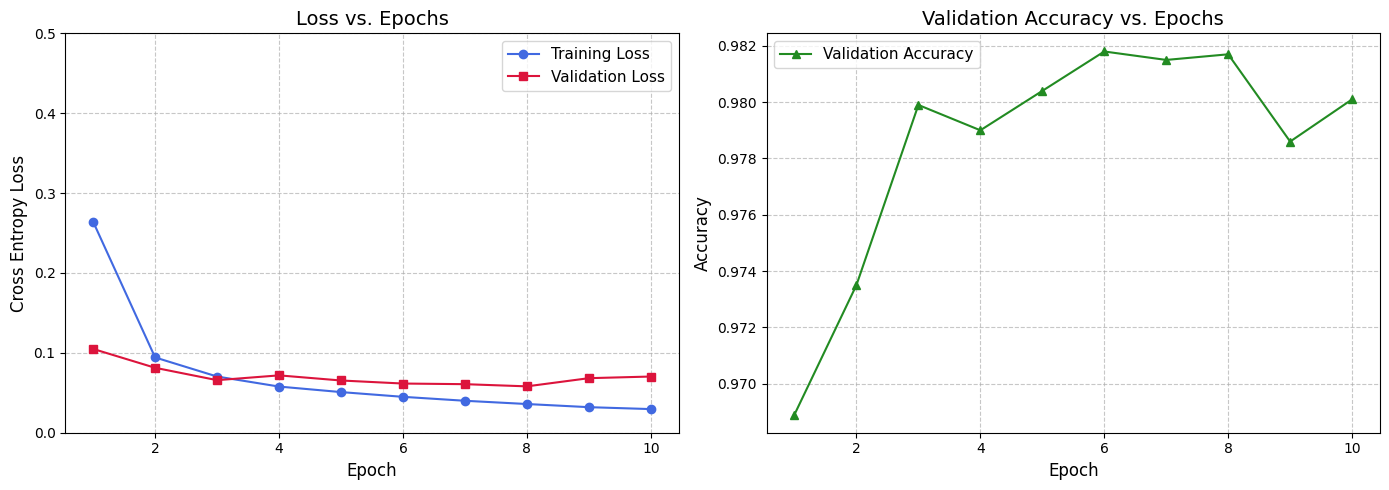

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Training vs. Validation Loss ---
ax1.plot(range(1, epochs + 1), train_loss_history, label='Training Loss', marker='o', color='royalblue')
ax1.plot(range(1, epochs + 1), val_loss_history, label='Validation Loss', marker='s', color='crimson')
ax1.set_title('Loss vs. Epochs', fontsize=14)
ax1.set_ylim(0,0.5)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Cross Entropy Loss', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Validation Accuracy ---
ax2.plot(range(1, epochs + 1), val_acc_history, label='Validation Accuracy', marker='^', color='forestgreen')
ax2.set_title('Validation Accuracy vs. Epochs', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## <b>Hyperparameter tuning with Optuna</b>

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.4 MB/s eta 0:00:00


In [ ]:
import optuna

def objective(trial):
    # Set up hyperparameter search space
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD", "RMSprop"])
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    # --- OPTIMIZED DATA PIPELINE ---
    # We use the globally loaded train_data and val_data to save I/O time
    trial_train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    trial_val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

    model = CNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = getattr(optim, optimizer_name)(model.parameters(), lr=lr)

    epochs = 5
    for e in range(epochs):
        model.train()
        for images, labels in trial_train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            pred = model(images)
            loss = criterion(pred, labels)
            loss.backward()
            optimizer.step()

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in trial_val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

# Run the study
if __name__ == "__main__":
    study = optuna.create_study(direction="maximize")
    print("Starting optimization...")
    study.optimize(objective, n_trials=10)
    print("\nBest hyperparameters:", study.best_trial.params)

[I 2026-06-03 10:41:57,416] A new study created in memory with name: no-name-72868696-c6a8-4ff8-b9aa-4b8e3d5161d9


Starting optimization...


[I 2026-06-03 10:43:12,341] Trial 0 finished with value: 0.9817 and parameters: {'lr': 0.000881434328958189, 'optimizer': 'RMSprop', 'batch_size': 64}. Best is trial 0 with value: 0.9817.
[I 2026-06-03 10:44:24,843] Trial 1 finished with value: 0.9808 and parameters: {'lr': 0.005776130308794331, 'optimizer': 'Adam', 'batch_size': 64}. Best is trial 0 with value: 0.9817.
[I 2026-06-03 10:45:46,330] Trial 2 finished with value: 0.9343 and parameters: {'lr': 0.05289034270391311, 'optimizer': 'RMSprop', 'batch_size': 32}. Best is trial 0 with value: 0.9817.
[I 2026-06-03 10:47:05,562] Trial 3 finished with value: 0.916 and parameters: {'lr': 0.0005035400989751308, 'optimizer': 'SGD', 'batch_size': 32}. Best is trial 0 with value: 0.9817.
[I 2026-06-03 10:48:14,095] Trial 4 finished with value: 0.9003 and parameters: {'lr': 0.0016401486484010723, 'optimizer': 'SGD', 'batch_size': 128}. Best is trial 0 with value: 0.9817.
[I 2026-06-03 10:49:34,464] Trial 5 finished with value: 0.913 and par


Best hyperparameters: {'lr': 0.000881434328958189, 'optimizer': 'RMSprop', 'batch_size': 64}


### <i>training the CNN on best hyperparams</i>

In [ ]:
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
lr = study.best_trial.params['lr']
optimizer_name = study.best_trial.params['optimizer']
batch_size = study.best_trial.params['batch_size']

optimizer = getattr(optim, optimizer_name)(model.parameters(), lr=lr)
epochs = 10
train_loss_history = []
val_loss_history = []
val_acc_history = []

print("Starting Training...\n")

for e in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    total_train_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # --- VALIDATION PHASE ---
    model.eval()
    total_val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad(): # Stop tracking gradients for validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_loss_history.append(avg_val_loss)

    val_accuracy = correct / total
    val_acc_history.append(val_accuracy)

    print(f"Epoch {e+1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.4f}")

Starting Training...

Epoch 01 | Train Loss: 0.2719 | Val Loss: 0.1123 | Val Acc: 0.9671
Epoch 02 | Train Loss: 0.0988 | Val Loss: 0.0812 | Val Acc: 0.9742
Epoch 03 | Train Loss: 0.0719 | Val Loss: 0.0704 | Val Acc: 0.9790
Epoch 04 | Train Loss: 0.0589 | Val Loss: 0.0610 | Val Acc: 0.9799
Epoch 05 | Train Loss: 0.0512 | Val Loss: 0.0612 | Val Acc: 0.9796
Epoch 06 | Train Loss: 0.0456 | Val Loss: 0.0555 | Val Acc: 0.9818
Epoch 07 | Train Loss: 0.0410 | Val Loss: 0.0590 | Val Acc: 0.9806
Epoch 08 | Train Loss: 0.0364 | Val Loss: 0.0592 | Val Acc: 0.9824
Epoch 09 | Train Loss: 0.0331 | Val Loss: 0.0542 | Val Acc: 0.9826
Epoch 10 | Train Loss: 0.0300 | Val Loss: 0.0584 | Val Acc: 0.9824


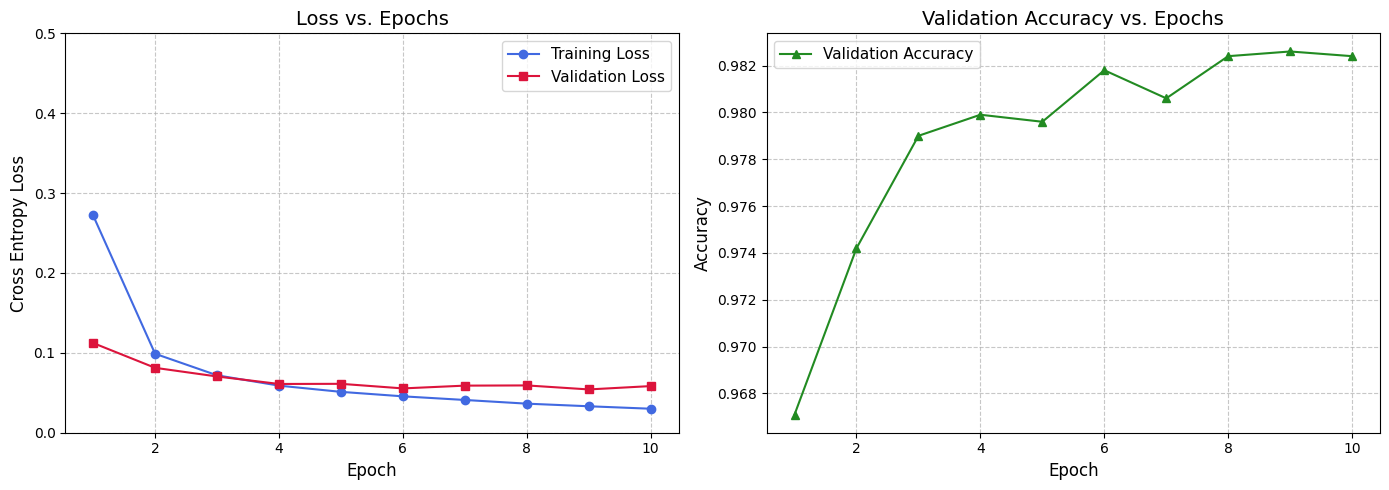

In [ ]:
# plotting training result with best hyperparams
# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Training vs. Validation Loss ---
ax1.plot(range(1, epochs + 1), train_loss_history, label='Training Loss', marker='o', color='royalblue')
ax1.plot(range(1, epochs + 1), val_loss_history, label='Validation Loss', marker='s', color='crimson')
ax1.set_title('Loss vs. Epochs', fontsize=14)
ax1.set_ylim(0,0.5)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Cross Entropy Loss', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Validation Accuracy ---
ax2.plot(range(1, epochs + 1), val_acc_history, label='Validation Accuracy', marker='^', color='forestgreen')
ax2.set_title('Validation Accuracy vs. Epochs', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## <b>Explaining the Model</b>

### <i>Visualizing images that activate a layer</i>

Each filter acts as a specific feature extractor. Some may detect blobs, other may detect edges. Visualizing which images maximally activates a layer (filter) is an empirical method to understand which filter in the convolution layer is doing the job of identifying a specific pattern.

In [ ]:
# settin up the hook
activations = {}
def get_activations(name):
  def hook(model, input, output):
    activations[name] = output.detach()
  return hook

# attaching the hook to the conv1 layer
model.conv1.register_forward_hook(get_activations('conv1'))

# recording the activations for all 4x4=16 filters
model.eval()
num_filters = 16

# initializing the dictionary to hold activation score with -inf for now
best_patches = {i: (-float('inf'), None) for i in range(num_filters)}

print(f"Scanning validation set across {num_filters} filters...\n")

with torch.no_grad():
  for images, labels in val_loader:
    images = images.to(device)
    _ = model(images)

    conv1_out = activations['conv1']  # shape : [batch,16,28,28]

    for i in range(images.size(0)):
      for f in range(num_filters):
        filter_map = conv1_out[i, f, :, :]
        score = torch.max(filter_map).item()

        # If this image scores higher than the current best for this filter, replace it
        if score > best_patches[f][0]:
          best_patches[f] = (score, images[i].cpu())

print("Validation complete")

Scanning validation set across 16 filters...

Validation complete


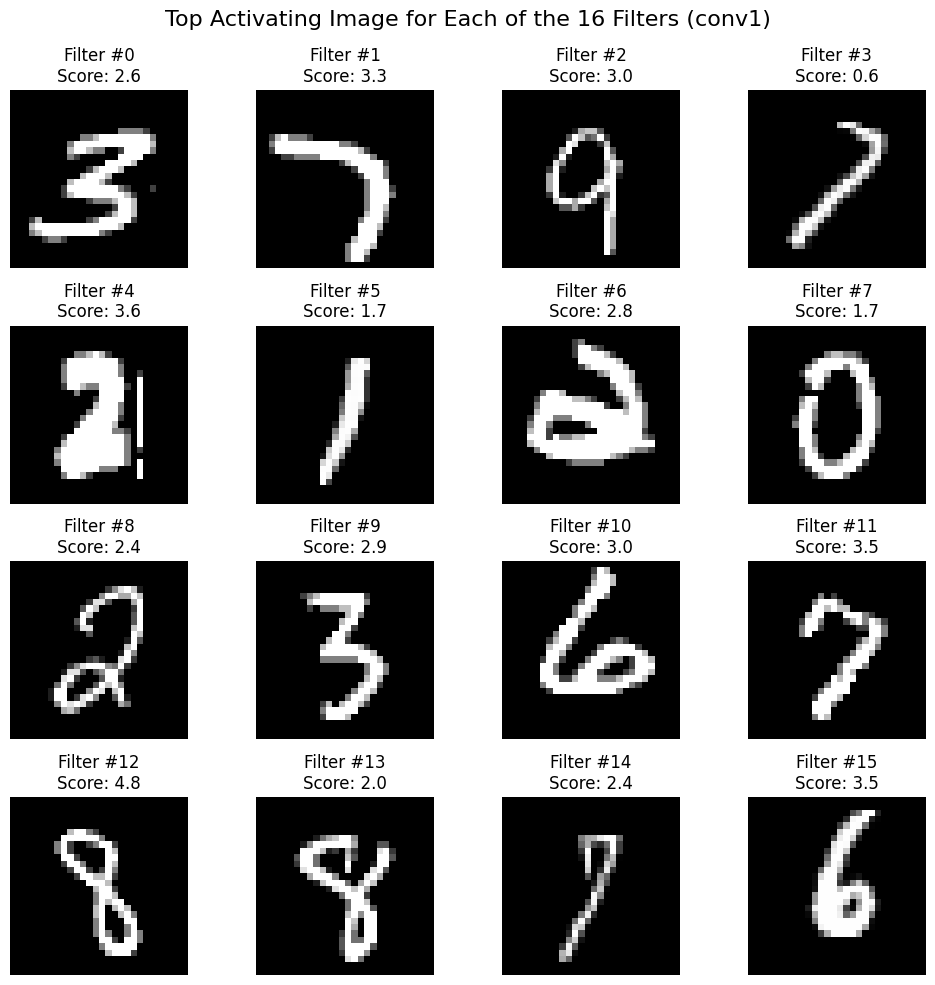

In [ ]:
# Visualizing
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('Top Activating Image for Each of the 16 Filters (conv1)', fontsize=16)

axes = axes.flatten()

for f in range(num_filters):
    score, img = best_patches[f]
    img = img.squeeze() * 0.5 + 0.5 # Un-normalize

    axes[f].imshow(img, cmap='gray')
    axes[f].set_title(f'Filter #{f}\nScore: {score:.1f}')
    axes[f].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

<h2><b>Interpreting Your New Filters</b></h2>

By looking at the new single most activating images for each filter, we can map out how the network redistributed its feature detection jobs:

* The Horizontal and Diagonal Edge Detectors (Filters #1, #3, and #11): These filters all maximally activated on the digit 7. This strongly suggests their internal weights have organized themselves into detectors for top-aligned horizontal roofs or stark diagonal stems.

* The Right-Facing Arc Detectors (Filters #0 and #9): Both of these activated on the digit 3. It is highly likely these filters are specializing in the double rounded curves on the right side of the canvas.

* The Curve and Loop Detectors (Filters #2, #7, #12, and #13): Filters #12 and #13 fired the absolute hardest for the digit 8, indicating a specialization in continuous intersecting curves. Filter #7 locked onto a 0 (a large continuous circular loop), and Filter #2 locked onto a 9 (a tight upper closed loop).

* The Vertical Edge and Glitch Detectors (Filters #4, #5, and #14): Filter #5 (a 1) and Filter #14 (a straight-stemmed 7) act as traditional vertical line detectors. Crucially, Filter #4 activated on a 2 that contains a glaring vertical white-line dataset artifact on the right edge. This proves once again that the network will lazily exploit image glitches if they mathematically align with a vertical edge filter.

<i> To test the hypothesis given above further, let's examine top 5 images for each filters insteado of a single image</i>

#### <i>Filter #**0**</i>

Scanning validation set for Filter #0...


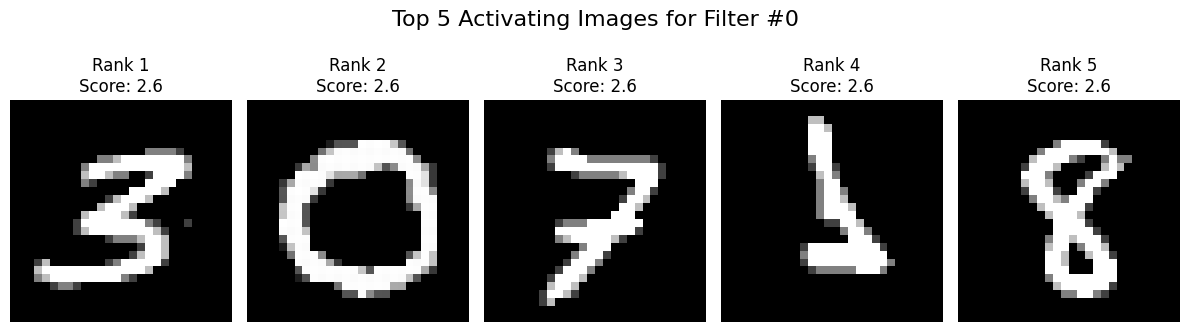

In [ ]:
model.eval()
target_filter = 0
image_scores = []

print(f"Scanning validation set for Filter #{target_filter}...")

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        _ = model(images)

        # Shape: [batch_size, 16_filters, 28_width, 28_height]
        conv1_out = activations['conv1']

        for i in range(images.size(0)):
            # Isolate the activation map specifically for our target filter
            filter_map = conv1_out[i, target_filter, :, :]
            score = torch.max(filter_map).item()

            # Append the score and the image (moved back to CPU for plotting)
            image_scores.append((score, images[i].cpu()))


# Sort the massive list descending based on the score
image_scores.sort(key=lambda x: x[0], reverse=True)

# Slice out the absolute Top 5
top_5 = image_scores[:5]

# VISUALIZE
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
fig.suptitle(f'Top 5 Activating Images for Filter #{target_filter}', fontsize=16, y=1.1)

for idx, (score, img) in enumerate(top_5):
    img = img.squeeze() * 0.5 + 0.5 # Un-normalize for matplotlib
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f'Rank {idx+1}\nScore: {score:.1f}')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

<i> The filter #0 is like a vertical edge-detector as can be clearly seen in Rank 3 (label = '4'). However, due to the image glitch, there are vertical lines even in images ranked 1, 4 and 5 ('2', '6', and '6' respectively). There are some straight vertical lines in '8' too, particularly on left and right side of the intersection, causing it to be ranked 2.

#### <i>For all other filters</i>

Scanning validation set for Filter #1...


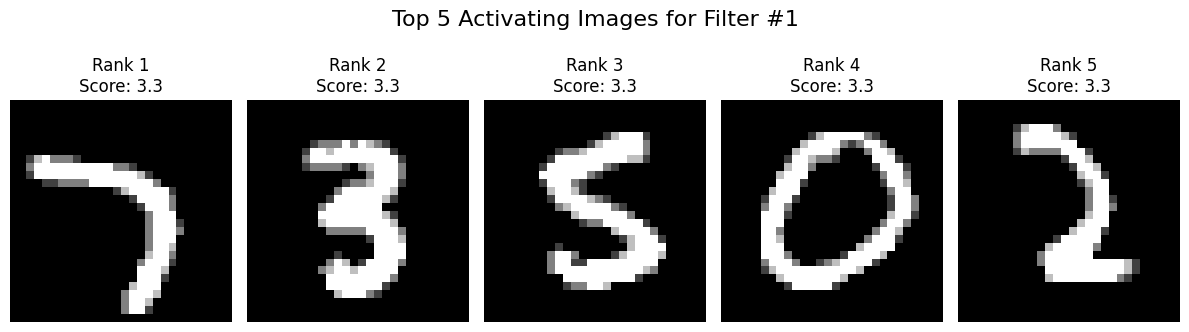

Scanning validation set for Filter #2...


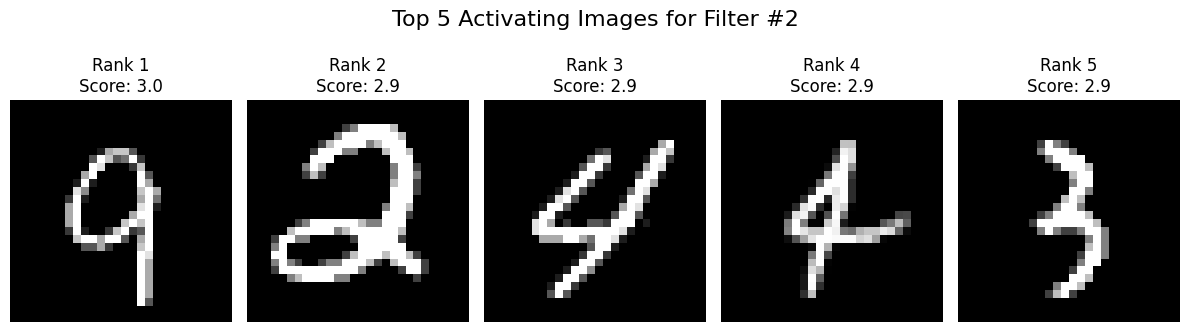

Scanning validation set for Filter #3...


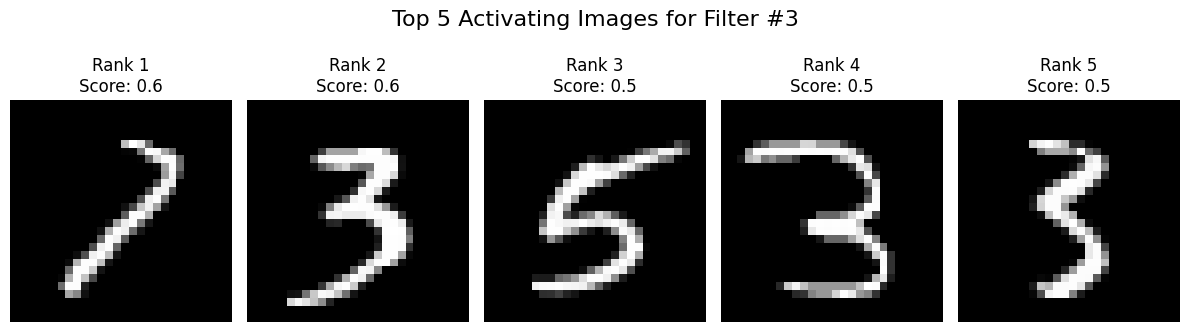

Scanning validation set for Filter #4...


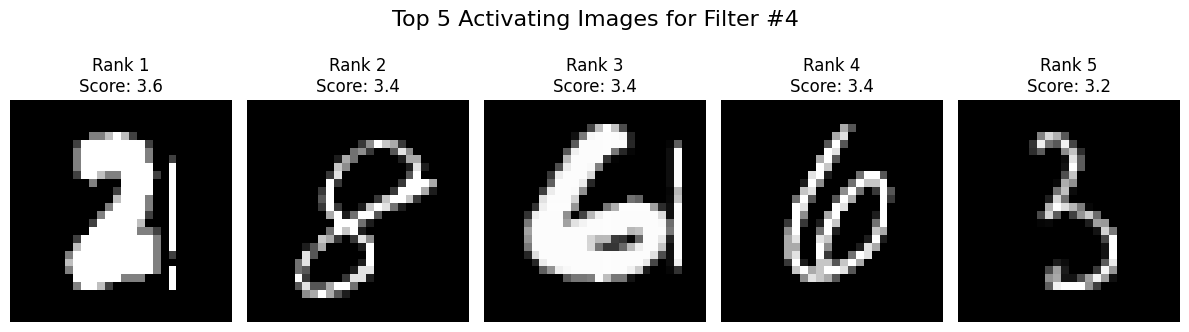

Scanning validation set for Filter #5...


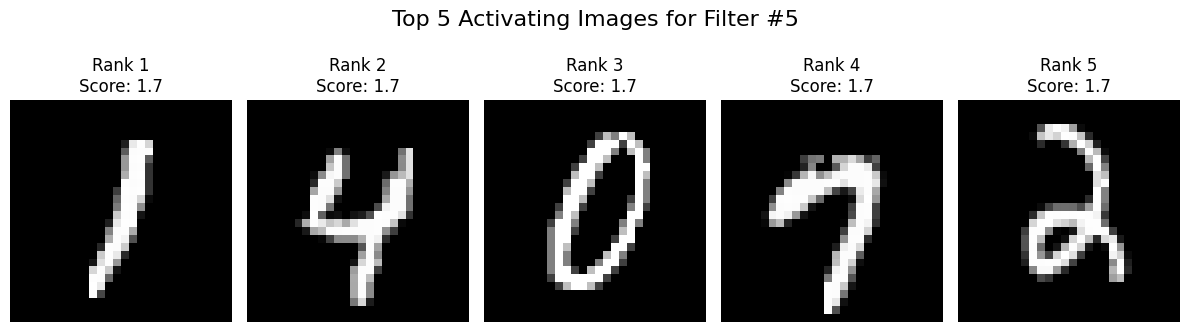

Scanning validation set for Filter #6...


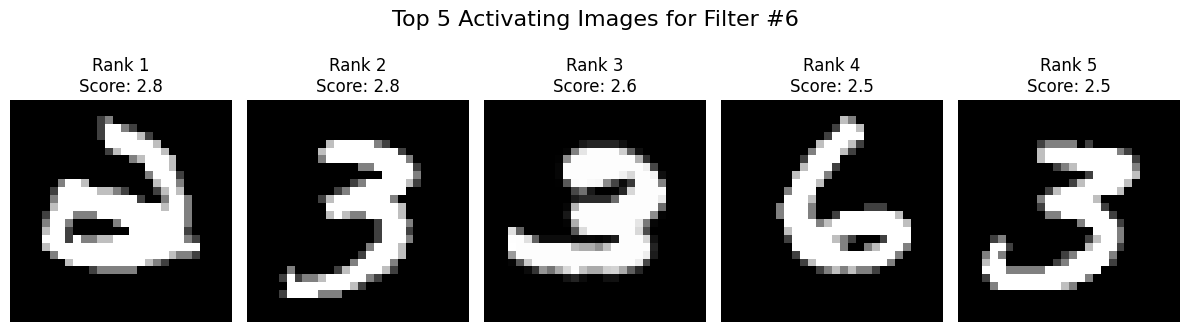

Scanning validation set for Filter #7...


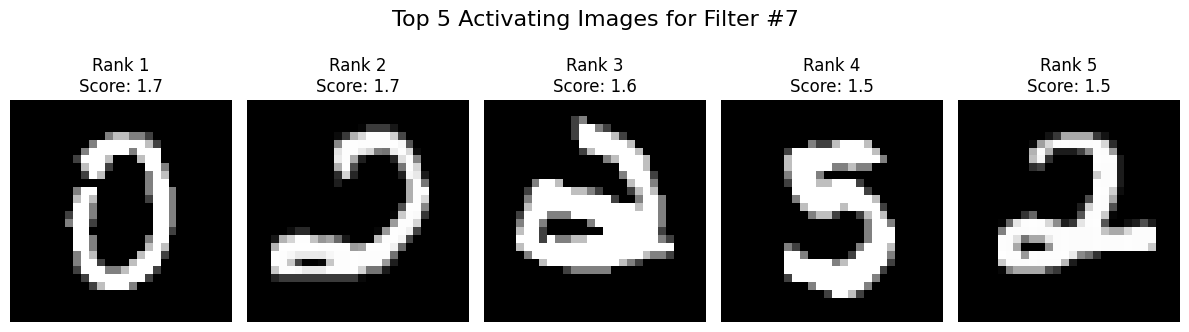

Scanning validation set for Filter #8...


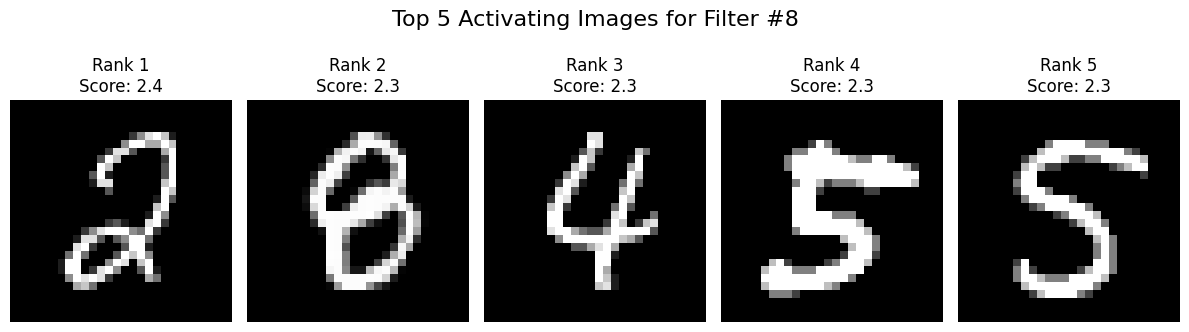

Scanning validation set for Filter #9...


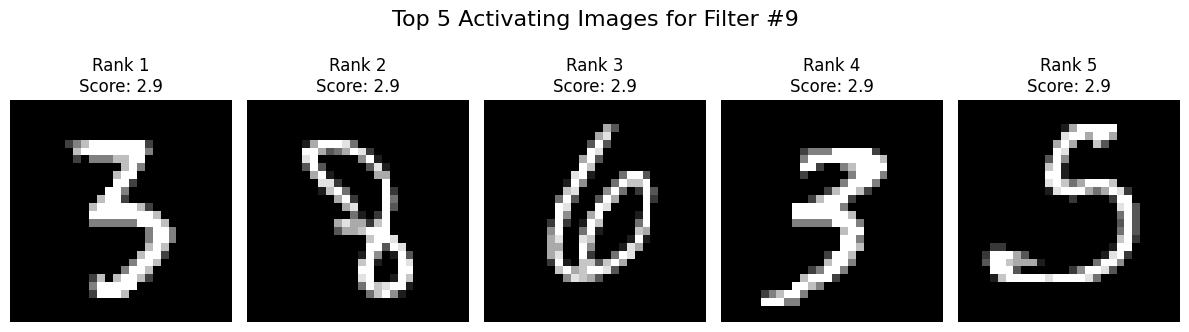

Scanning validation set for Filter #10...


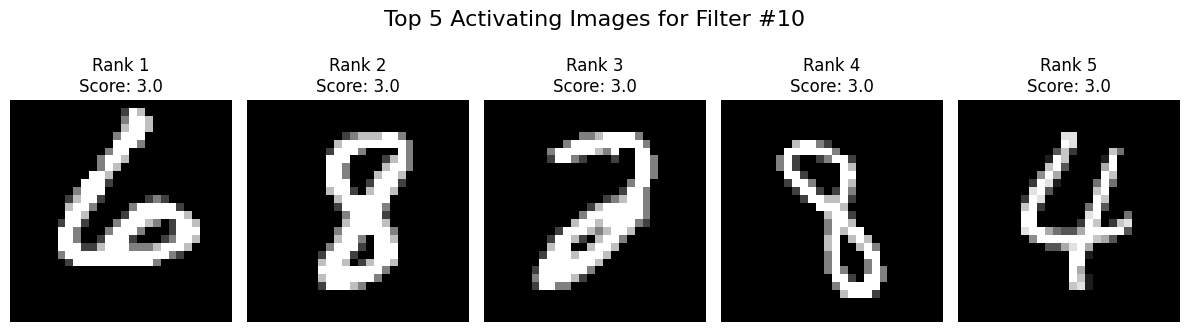

Scanning validation set for Filter #11...


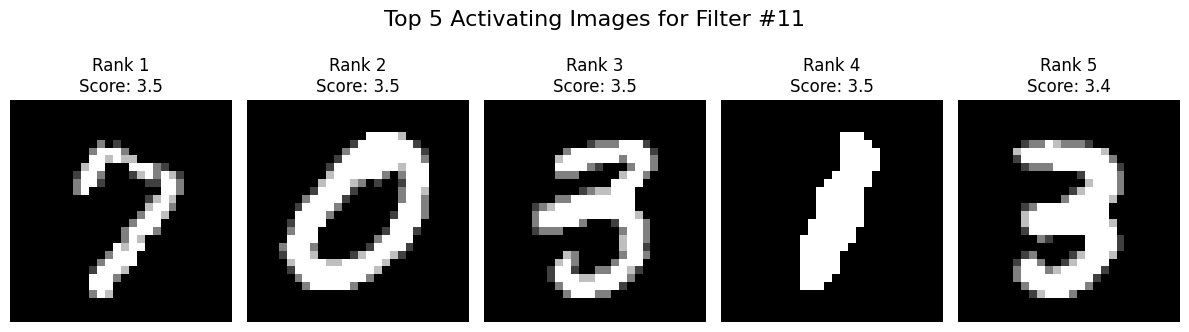

Scanning validation set for Filter #12...


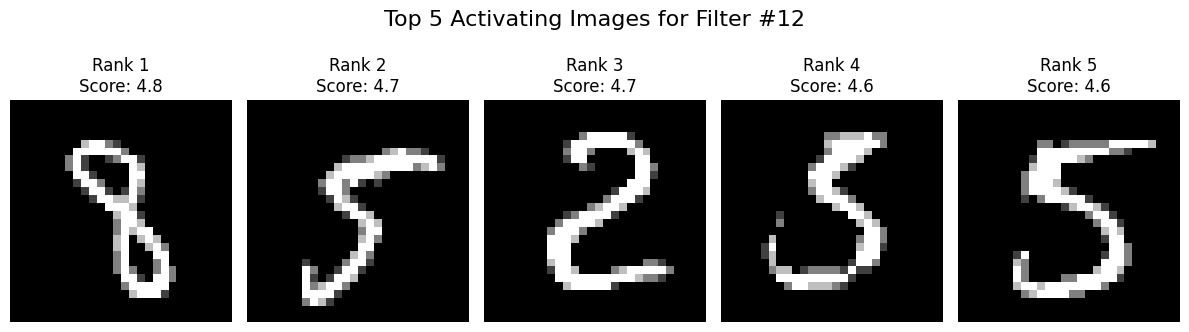

Scanning validation set for Filter #13...


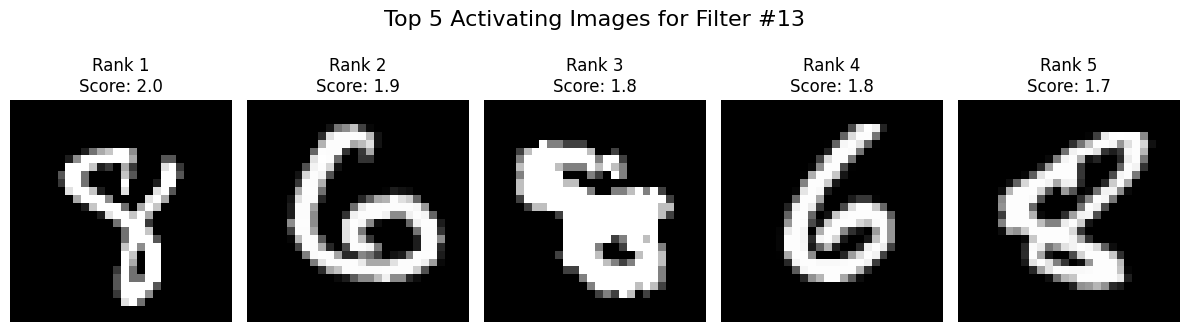

Scanning validation set for Filter #14...


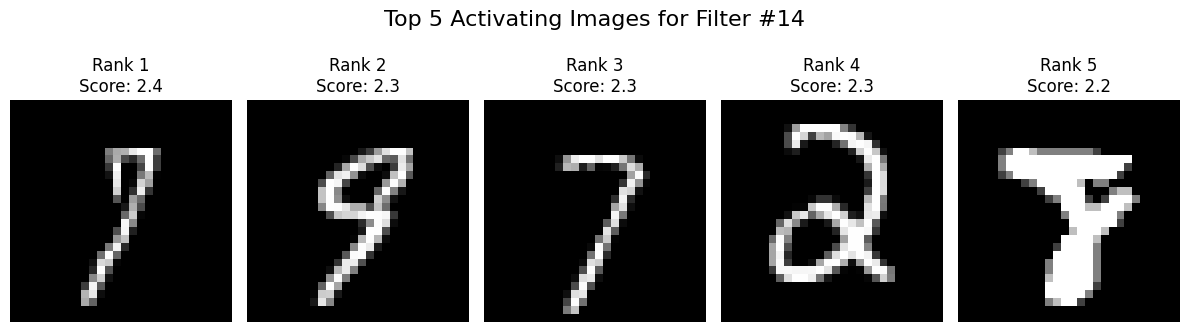

Scanning validation set for Filter #15...


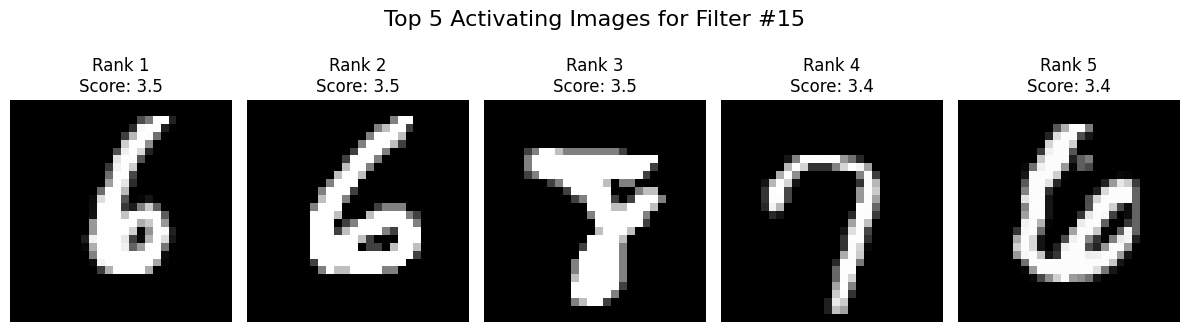

In [ ]:
num_filters = 16
for i in range(1, num_filters):
  model.eval()
  target_filter = i
  image_scores = []

  print(f"Scanning validation set for Filter #{target_filter}...")

  with torch.no_grad():
      for images, labels in val_loader:
          images = images.to(device)
          _ = model(images)

          # Shape: [batch_size, 16_filters, 28_width, 28_height]
          conv1_out = activations['conv1']

          for k in range(images.size(0)):
              # Isolate the activation map specifically for our target filter
              filter_map = conv1_out[k, target_filter, :, :]
              score = torch.max(filter_map).item()

              # Append the score and the image (moved back to CPU for plotting)
              image_scores.append((score, images[k].cpu()))


  # Sort the massive list descending based on the score
  image_scores.sort(key=lambda x: x[0], reverse=True)

  # Slice out the absolute Top 5
  top_5 = image_scores[:5]

  # VISUALIZE
  fig, axes = plt.subplots(1, 5, figsize=(12, 3))
  fig.suptitle(f'Top 5 Activating Images for Filter #{target_filter}', fontsize=16, y=1.1)

  for idx, (score, img) in enumerate(top_5):
      img = img.squeeze() * 0.5 + 0.5 # Un-normalize for matplotlib
      axes[idx].imshow(img, cmap='gray')
      axes[idx].set_title(f'Rank {idx+1}\nScore: {score:.1f}')
      axes[idx].axis('off')

  plt.tight_layout()
  plt.show()

### <i>Visualizing weights of neurons to understand which inputs cause them to fire</i>

A neuron is maximally fired if an input $x$ is close to the value $w/||w||$ where $w$ is the weight of the said neuron. This is a rather analytical method of testing which kind of input is most favoured by each filter.

Let's implement that and visualize it. To see the "perfect" input $x$ for each of the  16 filters, there is no need to pass any images through the network at all. We just need to plot the network's internal weights as if they were images.

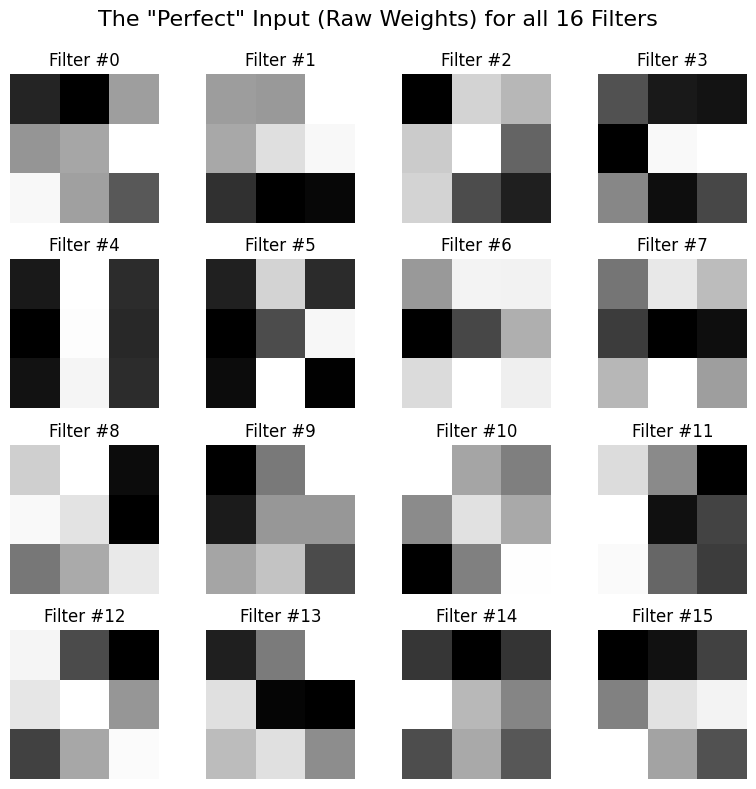

In [ ]:
# 1. Set up the weights matrix
weights = model.conv1.weight.data.cpu()

# 2. Visualize the weights as 3x3 image patches
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle('The "Perfect" Input (Raw Weights) for all 16 Filters', fontsize=16)

axes = axes.flatten()

for f in range(16):
    # Extract the 3x3 grid for this specific filter
    filter_weight = weights[f, 0, :, :]

    # Plot the weight matrix
    # Dark pixels = negative weights, Bright pixels = positive weights
    im = axes[f].imshow(filter_weight, cmap='gray')
    axes[f].set_title(f'Filter #{f}')
    axes[f].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

<b>filter-by-filter breakdown</b>

#### Filter #0 — Score: 2.6 → Digit: **3**
- Weights show dark top-left, light bottom-left — a diagonal gradient
- "3" has horizontal curves that sweep across the middle, matching this top-heavy contrast
- Medium score suggests partial match — the curves align but not perfectly

#### Filter #1 — Score: 3.3 → Digit: **1 (curved)**
- Weights are light top-centre, very dark bottom — strong vertical gradient
- The curved "1" (almost like a 7) has a bright arc at top and tapers down, matching the top-bright pattern
- Higher score reflects good alignment between the arc position and the light top weights

#### Filter #2 — Score: 3.0 → Digit: **9**
- Weights show dark top-left, light centre-right checkerboard pattern
- "9" has a closed loop at top-right and a descending tail — the bright right-centre of the weights matches the loop region
- The tail going down-left aligns with the darker bottom-left weights

#### Filter #3 — Score: 0.6 → Digit: **7**
- Weights are mostly dark with subtle variation — very low contrast
- The extremely low score (0.6) confirms this: the filter barely responds to anything
- The "7" is likely just the least-bad match from a weak, near-zero filter — this filter may not have learned anything meaningful

#### Filter #4 — Score: 3.6 → Digit: **2**
- Weights show two dark vertical columns flanking a lighter centre strip
- "2" has a thick rightward stroke at top and a base sweep — the vertical contrast columns align with the digit's strong horizontal boundaries
- Good score reflects solid structural match

#### Filter #5 — Score: 1.7 → Digit: **1**
- Weights have a bright patch at bottom-right, dark elsewhere — very localised response
- "1" is a thin vertical stroke — it barely covers any of the weight region, explaining the low score
- The bright bottom-right weight patch weakly matches where the digit's base sits

#### Filter #6 — Score: 2.8 → Digit: **2 (loopy)**
- Weights are light across the top half, dark bottom-left
- "2" here has a large curved loop at top and an open bottom — the bright top weights match the loop perfectly
- Dark bottom-left weight aligns with the open negative space in the digit's lower region

#### Filter #7 — Score: 1.7 → Digit: **0**
- Weights show a uniform mid-grey pattern with subtle variation — low contrast overall
- "0" is a closed oval loop — it activates the filter somewhat uniformly, which suits a flat weight distribution
- Low score because the filter has no strong preference — "0" is just the most symmetric digit available

#### Filter #8 — Score: 2.4 → Digit: **2**
- Weights show light top-left, dark right column — strong left-right contrast
- "2" has its main body on the left with open space on the right, matching this left-bright, right-dark pattern
- Moderate score — the match is reasonable but the digit's curves don't perfectly fill the weight map

#### Filter #9 — Score: 2.9 → Digit: **3**
- Weights show a relatively uniform mid-tone with slight centre emphasis
- "3" has two horizontal curves that distribute brightness fairly evenly across the centre — a good match for a centre-weighted filter
- The score reflects a decent but not exceptional alignment

#### Filter #10 — Score: 3.0 → Digit: **6**
- Weights show dark top-left, lighter bottom-right — a diagonal contrast
- "6" has an open top-left and a closed loop at bottom — the loop concentrates brightness in the bottom half, matching the lighter bottom-right weights
- Clean structural correspondence explains the solid score

#### Filter #11 — Score: 3.5 → Digit: **7**
- Weights show light top-right, dark bottom-left — a strong diagonal split
- "7" has its horizontal bar at top-right and a diagonal stroke going bottom-left — almost a perfect trace of the weight pattern
- High score reflects this direct geometric alignment

#### Filter #12 — Score: 4.8 → Digit: **8**
- Weights show alternating light/dark in a 2×2 checkerboard — the most structured pattern of all 16
- "8" has two loops creating bright regions in both the top and bottom halves — it fills the checkerboard pattern better than any other digit
- Highest score of all filters — best weight-to-digit structural match in the whole layer

#### Filter #13 — Score: 2.0 → Digit: **8 (open)**
- Weights show dark top-left and bottom-right, lighter elsewhere — an anti-diagonal pattern
- The open "8" (almost like an "&") has brightness distributed off-centre, loosely matching the anti-diagonal weights
- Low-moderate score — the digit is a rough match but the open style introduces misalignment

#### Filter #14 — Score: 2.4 → Digit: **7 (thin)**
- Weights show dark top and bottom with a lighter middle band
- The thin "7" has its horizontal stroke in the upper-middle region, partially matching the lighter centre weights
- Moderate score — the thin stroke doesn't fully saturate the weight map

#### Filter #15 — Score: 3.5 → Digit: **6**
- Weights show dark top-left, lighter centre and bottom-right
- "6" has an open top and a filled loop at the bottom-right — aligns well with where the lighter weights are concentrated
- Strong score reflects a good bottom-heavy brightness match

---

#### Overall takeaways
- **Filter #12** is the most selective and best-trained — its checkerboard pattern uniquely suits "8"
- **Filter #3** appears undertrained — near-zero weights mean it barely responds to anything
- **Digits 3, 2, 6, 7, 8** appear most frequently as top activators — they have the richest spatial contrast structure
- **Digit 1** only triggers low-scoring filters — its simple thin stroke is hard to match against spatially complex weight patterns

### Visualizing region importance using Grad-CAM

<h1><b>Grad-CAM</b></h1>

Grad-CAM (Gradient-weighted Class Activation Mapping) is a highly effective deep learning interpretability technique that uses the mathematics of backpropagation to instantly generate a glowing heatmap over the most important pixels of an image in a single pass. Instead of guessing what the neural network is looking at by covering things up, Grad-CAM directly asks the network, revealing exactly what the model is paying attention to and highlighting the specific features that drive its final prediction



1.   **The Forward Pass**: You feed an image into the network and get the final prediction scores.

2. **The Backward Pass** (The Trick): You pick the specific class you are interested in (e.g., the score for the digit '8') and run .backward(). But instead of updating the weights, you are just flowing the gradients backward to see how they behave.

3. **Intercepting the Gradients**: You use a "backward hook" to intercept the gradients right when they reach the final convolutional layer. (We use the final conv layer because it has the best balance of spatial resolution—knowing where things are—and semantic understanding—knowing what things are).

4. **Global Average Pooling (GAP)**: You average out the gradients for each filter to get a single number. This number is an "Importance Weight." If Filter #10 has a huge positive weight, it means Filter #10 is highly responsible for the network predicting '8'.

5. **The Heatmap**: You multiply the activation maps by their Importance Weights, add them all together, and pass them through a ReLU function (so we only keep the features that positively influence the '8' prediction).


In [16]:
import torch.nn.functional as F

# Step 1: set up the hooks
grad_cam_data = {'activations': None, 'gradients': None}

# Hook to save the features from the forward pass
def forward_hook(module, input, output):
    grad_cam_data['activations'] = output.detach()

# Hook to save the gradients from the backward pass
def backward_hook(module, grad_in, grad_out):
    grad_cam_data['gradients'] = grad_out[0].detach()

# Attach the hooks to your conv1 layer
model.conv1.register_forward_hook(forward_hook)
model.conv1.register_backward_hook(backward_hook)

# Step 2: select an image
model.eval()
images, label = next(iter(val_loader))
img = images[0].unsqueeze(0).to(device)   # grab the very first image
actual_label = label[0].item()

# Step 3: Grad-CAM pass
model.zero_grad()
outputs = model(img)
# Get the network's top prediction
predicted_class = outputs.argmax(dim=1).item()
target_score = outputs[0, predicted_class]

# Flow the gradients backward from that specific prediction
target_score.backward()

# Step 4: The actual Grad-CAM math
acts = grad_cam_data['activations'][0]
grads = grad_cam_data['gradients'][0]

# calculate importance weights via GAP
weights = torch.mean(grads, dim=(1,2))

# create an empty heatmap canvas
cam = torch.zeros(acts.shape[1:], dtype=torch.float32, device=device)

# multiply each filter's map by its importance weight and add to the canvas
for i, w in enumerate(weights):
  cam += w * acts[i]

# apply ReLU to keep only positive activations
cam = F.relu(cam)

# normalize the cam for heatmapping
cam -= torch.min(cam)
cam /= torch.max(cam)
cam = cam.cpu().numpy()

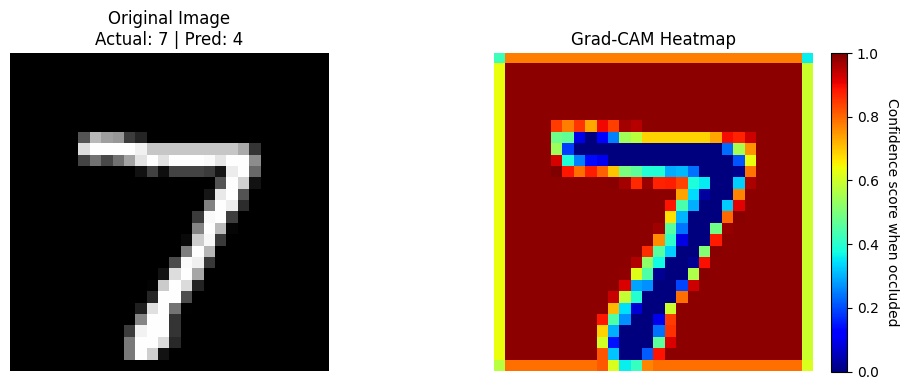

In [17]:
# --- 5. VISUALIZATION WITH COLORBAR ---
original_img = img.squeeze().cpu().numpy() * 0.5 + 0.5 # Un-normalize

# Changed to 2 subplots instead of 3
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot 1: Original Image
axes[0].imshow(original_img, cmap='gray')
axes[0].set_title(f'Original Image\nActual: {actual_label} | Pred: {predicted_class}')
axes[0].axis('off')

# Plot 2: Grad-CAM Heatmap
heatmap = axes[1].imshow(cam, cmap='jet')
axes[1].set_title('Grad-CAM Heatmap')
axes[1].axis('off')

# Add the color gradient legend (colorbar) attached to Plot 2
cbar = fig.colorbar(heatmap, ax=axes[1], fraction=0.046, pad=0.04)
cbar.set_label('Confidence score when occluded', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

## <b>Summary</b>

Project Conclusion & Key Takeaways

In this project, we successfully engineered, optimized, and reverse-engineered a Convolutional Neural Network (CNN) for MNIST digit classification. Rather than treating the neural network as an uninterpretable "black box," we systematically dismantled its decision-making process using techniques from the broader landscape of Deep Learning Interpretability.

1. Architecture & Hyperparameter Optimization
We built a mathematically sound CNN foundation, moving beyond standard training loops to implement real-time validation tracking. By utilizing Optuna, we dynamically optimized our hyperparameter search space (learning rate, optimizer, and batch size), ensuring the model learned generalizable patterns without overfitting.

2. Feature Visualization ("What is the network looking for?")
Deep Learning interpretability begins with understanding internal representations. We implemented Forward Hooks to "wiretap" the conv1 layer. By analyzing the raw 3×3 weight matrices and empirically finding the top-activating image patches, we proved that the network organically organized its filters into geometric feature detectors (e.g., vertical edges, horizontal gaps). This aligns with the goals of Feature Visualization techniques like Activation Maximization, proving the network learns a hierarchy of structural components.

3. Attribution Methods ("Where is the network looking?")
To understand the spatial reasoning behind specific predictions, we utilized Attribution Methods.

    Activation/Gradient-Based: We implemented Grad-CAM to map the network's global visual attention. By flowing gradients backward, we generated heatmaps proving the model’s confidence is anchored entirely in sharp contrasting boundaries and structural intersections, not the holistic "concept" of a digit.

    Perturbation-Based: We explored the foundational logic of occlusion (masking parts of the image to measure confidence drops), which sits in the same family of state-of-state explainers as LIME and SHAP.

4. The Broader XAI Landscape
The techniques implemented in this notebook—empirical feature visualization and Grad-CAM—serve as the foundation for modern Explainable AI. As models scale beyond MNIST into complex, high-resolution domains, these core concepts directly pave the way for more advanced diagnostic tools, including gradient-based methods (SmoothGrad, Integrated Gradients) and high-level concept explanations (TCAV). We have not just trained a model to predict numbers; we have mathematically proven how and why it sees them.